In [ ]:
# ==========================================
# 1. Libraries
# ==========================================
import pandas as pd
import numpy as np
from darts import TimeSeries
from darts.models import NHiTSModel
from darts.dataprocessing.transformers import Scaler
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
import os
from darts.models import NHiTSModel
import holidays
import joblib

In [3]:
# ==========================================
# 2. Load Data
# ==========================================
# df must have: date, store, item, sales
df = pd.read_csv("dataset/df.csv")

In [4]:
df['date'] = pd.to_datetime(df['date'],format='%d-%m-%Y')

In [5]:
 #==========================================#
# 3. Feature Engineering
# ==========================================
india_holidays = holidays.India()

df['date'] = pd.to_datetime(df['date'])

df['is_holiday'] = df['date'].apply(lambda x: int(x in india_holidays))
df['dow'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

df = df.rename(columns={'date': 'ds', 'sales': 'y'})

In [6]:
# ==========================================
# 4. Build Series
# ==========================================
series_list = []
covariates_list = []
keys = []

for (store, item), group in df.groupby(['store', 'item']):
    
    group = group.sort_values('ds')
    key = f"{store}_{item}"
    
    ts = TimeSeries.from_dataframe(
        group,
        time_col='ds',
        value_cols='y'
    )
    
    cov = TimeSeries.from_dataframe(
        group,
        time_col='ds',
        value_cols=['is_holiday', 'dow', 'month']
    )

    series_list.append(ts)
    covariates_list.append(cov)
    keys.append(key)

In [7]:
# ==========================================
# 5. Train/Test Split
# ==========================================
test_size = 90

train_series = []
test_series = []
train_cov = []
test_cov = []

for ts, cov in zip(series_list, covariates_list):
    
    train_series.append(ts[:-test_size])
    test_series.append(ts[-test_size:])
    
    train_cov.append(cov[:-test_size])
    test_cov.append(cov)  


In [8]:
# ==========================================
# 6. Scaling
# ==========================================
scaler_series = Scaler()
scaler_cov = Scaler()

train_series_scaled = scaler_series.fit_transform(train_series)
train_cov_scaled = scaler_cov.fit_transform(train_cov)

# ==========================================
# 7. Model
# ==========================================

model = NHiTSModel(
    input_chunk_length=365,       
    output_chunk_length=90,       
    n_epochs=30,                 
    random_state=42,

    num_layers=3,
    dropout=0.1,                  
    activation="ReLU"
)

In [ ]:

model_path = "darts_model/NHITS_model.pth"

try:
    # Try loading existing model
    model = NHiTSModel.load(model_path)
    print("Model loaded successfully.")

except (FileNotFoundError, IOError, RuntimeError) as e:
    print(f"Loading failed: {e}")
    print("Training a new NHiTS model...")

    model = NHiTSModel(
        input_chunk_length=365,       
        output_chunk_length=90,       
        n_epochs=30,                 
        random_state=42,
        num_layers=3,
        dropout=0.1,                  
        activation="ReLU"
    )

    model.fit(
        series=train_series_scaled,
        past_covariates=train_cov_scaled,
        verbose=True
    )

    # Ensure directory exists
    os.makedirs("darts_model", exist_ok=True)

    model.save(model_path)
    print("Model trained and saved.")

In [ ]:


model_dir = "darts_model/NHITS_model"   # use a directory, not .pth

try:
    # Try loading existing model
    model = NHiTSModel.load(model_dir)
    print("Model loaded successfully.")

except (FileNotFoundError, IOError, RuntimeError) as e:
    print(f"Loading failed: {e}")
    print("Training a new NHiTS model...")

    model = NHiTSModel(
        input_chunk_length=365,
        output_chunk_length=90,
        n_epochs=30,
        random_state=42,
        num_layers=3,
        dropout=0.1,
        activation="ReLU"
    )

    model.fit(
        series=train_series_scaled,
        past_covariates=train_cov_scaled,
        verbose=True
    )

    # Ensure directory exists
    os.makedirs("darts_model2", exist_ok=True)

    model.save(model_dir)   # save to directory
    print("Model trained and saved.")


Loading failed: [Errno 2] No such file or directory: 'darts_model/NHITS_model'
Training a new NHiTS model...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 3.5 M  | train | 0    
---------------------------------------------------------------------
2.7 M     Trainable params
748 K     Non-trainable params
3.5 M     Total params
27.977    Total estimated

Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# ==========================================
# 9. Prediction
# ==========================================
pred_scaled = model.predict(
    n=90,
    series=train_series_scaled,
    past_covariates=scaler_cov.transform(test_cov)
)

pred = scaler_series.inverse_transform(pred_scaled)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
D:\anconda\envs\python_ds11\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
D:\anconda\envs\python_ds11\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting: |                                                                                    | 0/? [00:00<…

In [ ]:
# ==========================================
# 10. FUTURE FORECAST
# ==========================================

future_cov_list = []

full_series_scaled = scaler_series.transform(series_list)
full_series_scaled = list(full_series_scaled)   

for i, ((store, item), group) in enumerate(df.groupby(['store', 'item'])):
    
    last_date = group['ds'].max()
    
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=90
    )
    
    future_df = pd.DataFrame({'ds': future_dates})
    
    future_df['is_holiday'] = future_df['ds'].apply(lambda x: int(x in india_holidays))
    future_df['dow'] = future_df['ds'].dt.dayofweek
    future_df['month'] = future_df['ds'].dt.month
    
    future_cov = TimeSeries.from_dataframe(
        future_df,
        time_col='ds',
        value_cols=['is_holiday', 'dow', 'month']
    )
    
    full_cov = covariates_list[i].append(future_cov)
    future_cov_list.append(full_cov)

future_cov_scaled = scaler_cov.transform(future_cov_list)

future_pred_scaled = model.predict(
    n=90,
    series=full_series_scaled,
    past_covariates=future_cov_scaled
)

future_pred = scaler_series.inverse_transform(future_pred_scaled)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
D:\anconda\envs\python_ds11\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
D:\anconda\envs\python_ds11\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting: |                                                                                    | 0/? [00:00<…

In [ ]:
# ==========================================
# 11. Evaluation
# ==========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

rmse_list, mae_list, mape_list,r_square_list = [], [], [], []

for true, forecast in zip(test_series, pred):
    
    y_true = true.values().flatten()
    y_pred = forecast.values().flatten()
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    rsq = r2_score(y_true=y_true,y_pred=y_pred)
    rmse_list.append(rmse)
    mae_list.append(mae)
    mape_list.append(mape)
    r_square_list.append(rsq)
print("RMSE:", np.mean(rmse_list))
print("MAE:", np.mean(mae_list))
print("MAPE:", np.mean(mape_list))
print('rsq:', np.mean(r_square_list))

RMSE: 7.793528421777458
MAE: 6.195721865038904
MAPE: 13.086129954748849
rsq: 0.5670228820277129


In [ ]:
import matplotlib.pyplot as plt

def plot_forecast(train_series, test_series, pred_series, future_series, title="Forecast"):

    plt.figure(figsize=(14,6))
    
    # Train (actual)
    train_series.plot(label="Train", linewidth=2)
    
    # Test (actual)
    test_series.plot(label="Test", linewidth=2)
    
    # Backtest prediction
    pred_series.plot(label="Forecast (Test Period)", linewidth=2)
    
    # Future forecast (NEW)
    future_series.plot(label="Future Forecast (90D)", linewidth=2)
    
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

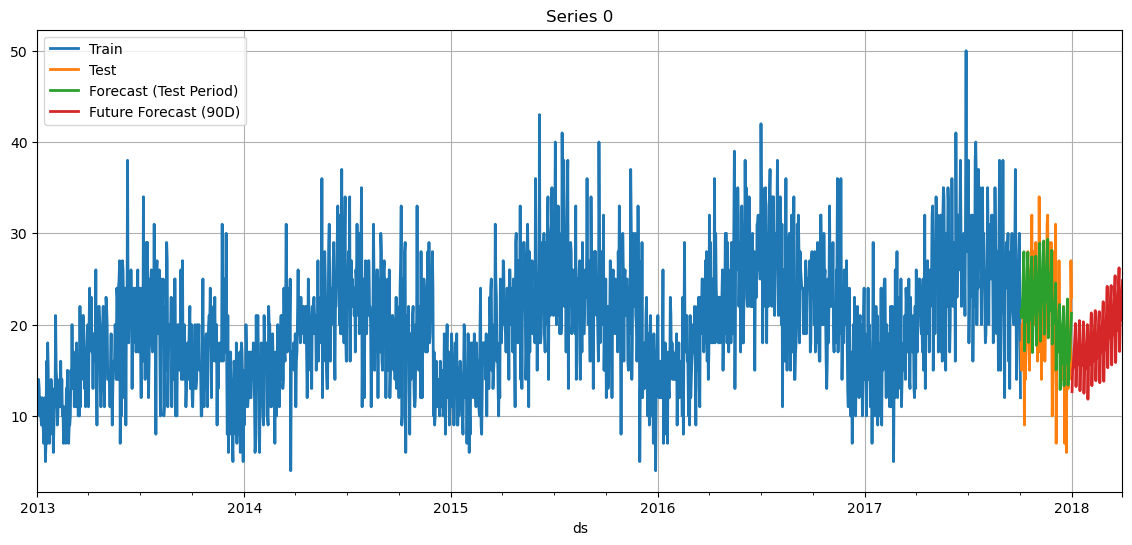

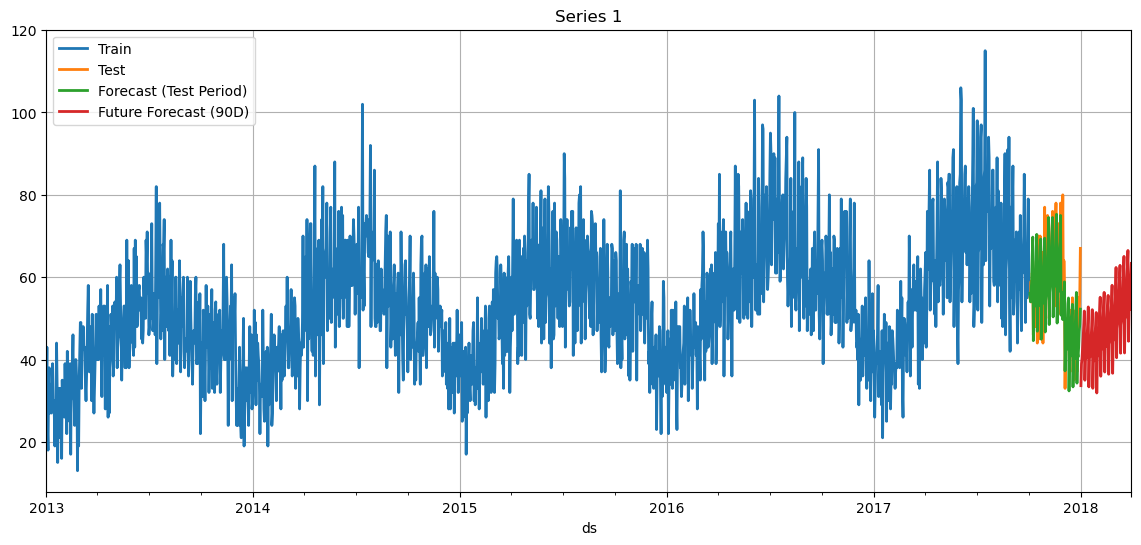

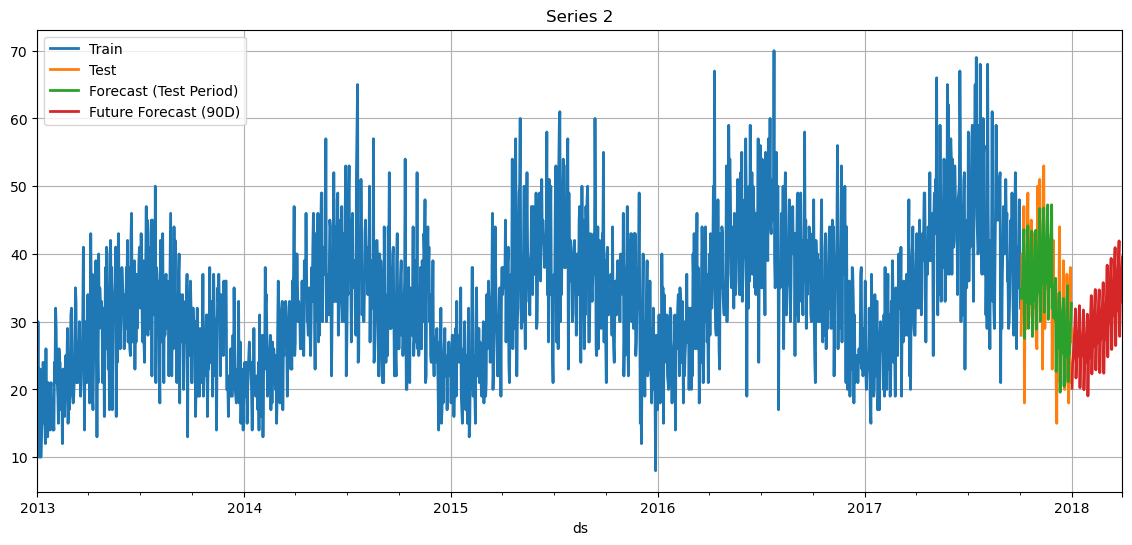

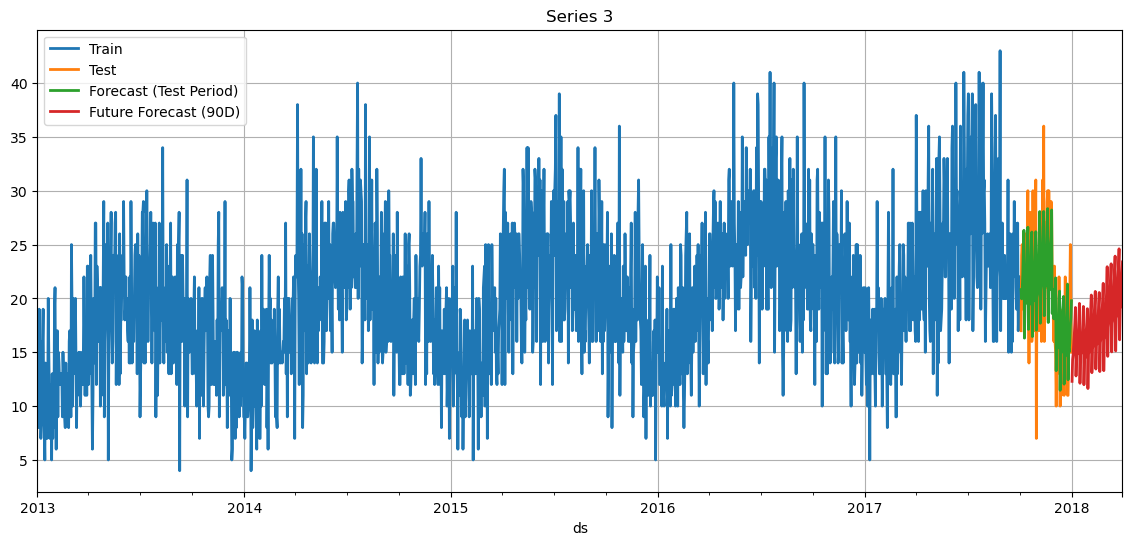

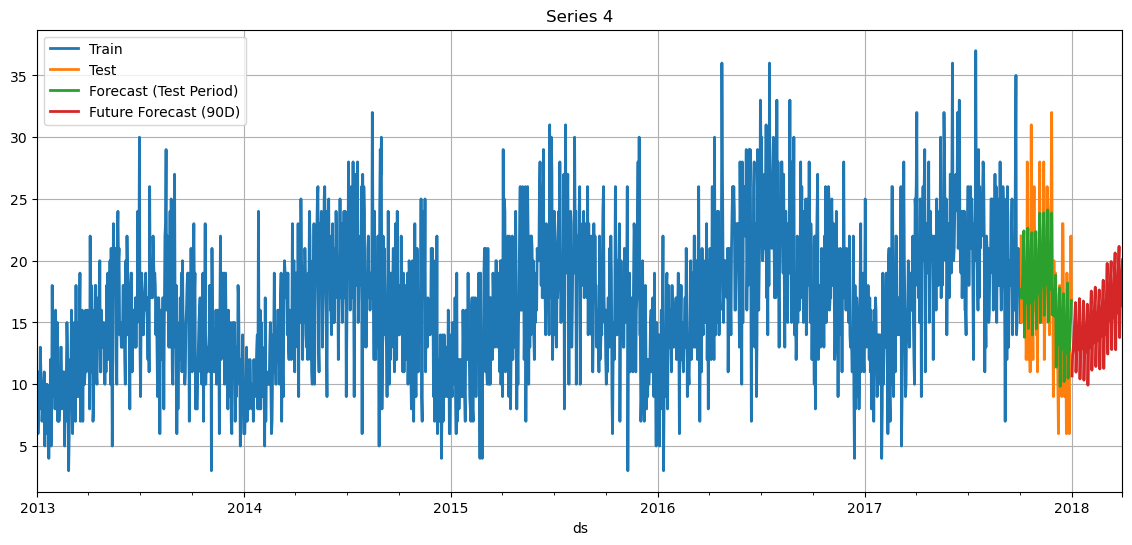

In [ ]:
for i in range(5):  # first 5 series
    
    plot_forecast(
        train_series[i],
        test_series[i],
        pred[i],
        future_pred[i],
        title=f"Series {i}"
    )

In [ ]:
def series_to_df(ts, label, key):
    df = ts.to_dataframe().reset_index()   # ✅ FIX
    df['type'] = label
    df['unique_id'] = key
    return df

all_dfs = []

for i, ((store, item), _) in enumerate(df.groupby(['store','item'])):
    key = f"{store}_{item}"
    
    all_dfs.append(series_to_df(train_series[i], "train", key))
    all_dfs.append(series_to_df(test_series[i], "test", key))
    all_dfs.append(series_to_df(pred[i], "forecast", key))
    all_dfs.append(series_to_df(future_pred[i], "future", key))

final_df = pd.concat(all_dfs)

final_df.to_csv("forecast_dashboard_data.csv", index=False)